In [12]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
import mc_simulation as mc


In [13]:
# Basic parameters

sigma_0 = 1.0     # Hard-core diameter
sigma_1 = 2.5     # Soft-shoulder diameter
epsilon = 1.0     # Energy unit
T_target = 0.1    # Target temperature for task 1

### Optimal $\delta $ parameters

In [14]:
# The proposed function for the model
def exp_decay(delta, A0, k):
    return A0 * np.exp(-k * delta)

# The analytical function to get optimal step size for target acceptance
def calculate_optimal_delta(A0_fit, k_fit, target_acceptance=0.30):
    return -np.log(target_acceptance / A0_fit) / k_fit

# Input parameter grid matching the simulation values 
step_sizes = np.array([0.05, 0.10, 0.18, 0.25, 0.35, 0.50, 0.65, 0.80])

# Load the parameters from the simulation
loaded_data = np.load("simulation_results_findingdelta.npz")
results = {float(k): loaded_data[k] for k in loaded_data.files}

# 3. Fit curves and derive optimal delta for each density
optimal_deltas = {}
fit_params = {}

print("Density (rho) | Fitted A0 | Fitted k | Optimal Delta (Target 30%)")
print("-" * 65)

for rho, acc_rates in sorted(results.items()):
    # Initial guesses - to make the fit easier A0 ~ 1.0 (100% acceptance at delta=0), k ~ 1.5 decay rate
    p0 = [1.0, 1.5]
    
    # Fitting the curves
    popt, pcov = curve_fit(exp_decay, step_sizes, acc_rates, p0=p0)
    A0_fit, k_fit = popt
    
    # Compute the optimal delta that yields target acceptance (30% was suggested in the task papaer)
    delta_opt = calculate_optimal_delta(A0_fit, k_fit, target_acceptance=0.30)
    
    # Store the resutls
    fit_params[rho] = (A0_fit, k_fit)
    optimal_deltas[rho] = delta_opt
    
    print(f"   {rho:.3f}      |  {A0_fit:.4f}  |  {k_fit:.4f}  |      {delta_opt:.4f}")

Density (rho) | Fitted A0 | Fitted k | Optimal Delta (Target 30%)
-----------------------------------------------------------------
   0.100      |  0.9958  |  1.0750  |      1.1160
   0.150      |  1.0545  |  2.7982  |      0.4492
   0.227      |  1.0425  |  4.3817  |      0.2843
   0.291      |  1.0163  |  5.4403  |      0.2243
   0.380      |  1.0196  |  7.1703  |      0.1706


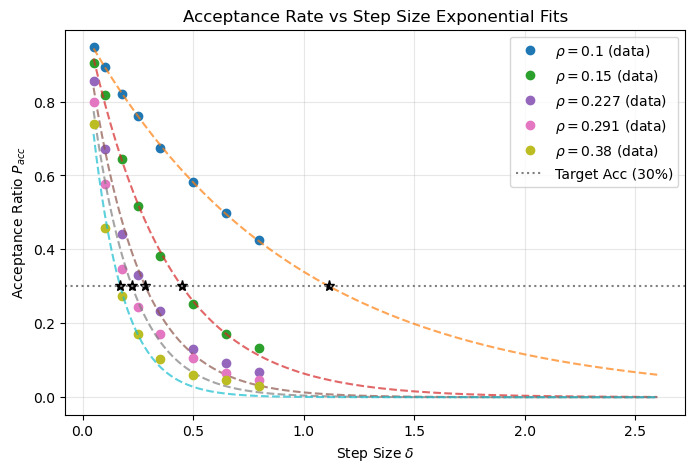

In [15]:
# Visualize the results
plt.figure(figsize=(8, 5))
delta_dense = np.linspace(0.05, 2.6, 200)

for rho, acc_rates in sorted(results.items()):
    A0_fit, k_fit = fit_params[rho]
    delta_opt = optimal_deltas[rho]
    
    # Scatter plot of simulation sweeps
    plt.plot(step_sizes, acc_rates, 'o', label=f"$\\rho = {rho}$ (data)")
    
    # Plot the analytical fitted solution
    fit_curve = exp_decay(delta_dense, A0_fit, k_fit)
    plt.plot(delta_dense, fit_curve, '--', alpha=0.7)
    
    # Mark the targeted value of 0.3
    plt.plot(delta_opt, 0.30, 'k*', markersize=8)

plt.axhline(0.30, color='gray', linestyle=':', label='Target Acc (30%)')
plt.xlabel("Step Size $\\delta$")
plt.ylabel("Acceptance Ratio $P_{acc}$")
plt.title("Acceptance Rate vs Step Size Exponential Fits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Test simulation: 

In [16]:
import mc_simulation as mc

In [25]:
optimal_deltas

{0.1: 1.115990506145163,
 0.15: 0.4492237770404882,
 0.227: 0.2842732149098073,
 0.291: 0.22426948048395018,
 0.38: 0.17061669225176934}

=== Starting Phase A Sweep: N=100, T*=0.1 ===

 Running Density rho* = 0.1


Equilibrating (rho*=0.1):   0%|          | 0/1000000 [00:00<?, ?move/s]

Equilibration Finished (rho*=0.1) | Acceptance: 31.46%


Production   (rho*=0.1):   0%|          | 0/10000000 [00:00<?, ?move/s]

Production Finished   (rho*=0.1) | Acceptance: 31.38%



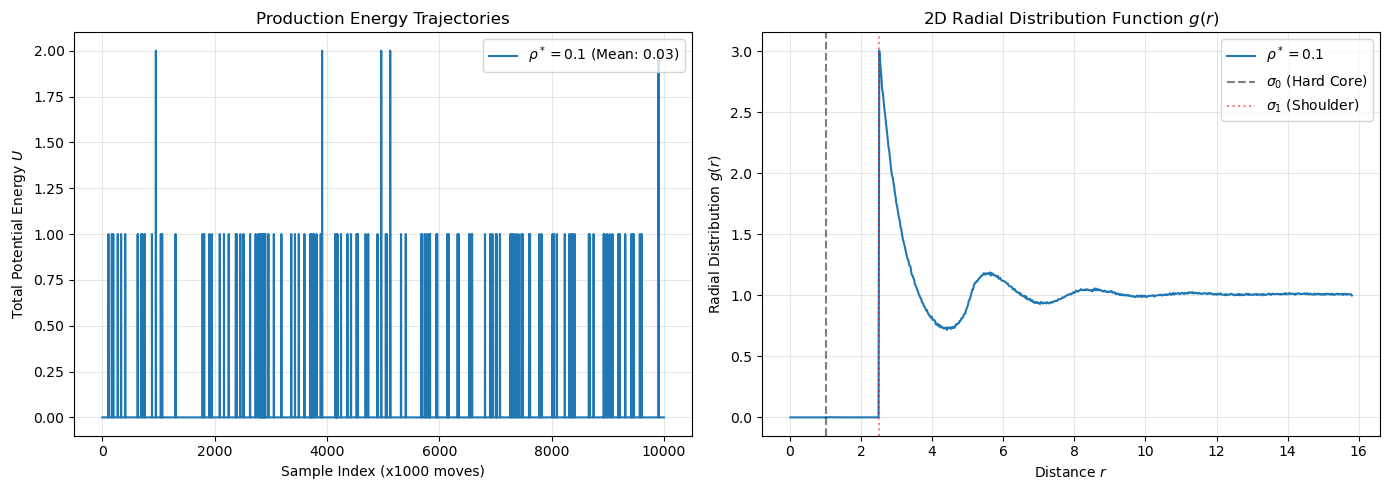

In [26]:
# Simulation Parameters 
N = 100
T_star = 0.1
densities = [0.10]

delta = optimal_deltas[0.1]
eq_moves = 1_000_000        # 1M moves for equilibration
prod_moves = 10_000_000      # 10M moves for production sampling
sample_interval = 1_000     # Sample trajectory every 1,000 steps

results = {}

print(f"=== Starting Phase A Sweep: N={N}, T*={T_star} ===")

for rho in densities:
    print(f"\n" + "="*50)
    print(f" Running Density rho* = {rho}")
    print("="*50)

    # Create a random layout
    x, y = mc.hot_start(N=N, rho=rho)

    # Pre-equilibration to remove hard-core overlaps
    x, y, success, sweeps = mc.pre_equilibrate(
        x, y, T_high=100, U_cap=800, delta_pre_eq=0.50, rho=rho, N=N
    )
    if not success:
        print(f"Warning: Pre-equilibration failed for rho*={rho}")
        continue

    # Equilibration - 10^6 Steps
    x, y, eq_moves_hist, eq_e_hist, eq_acc = mc.equilibrate_continuous(
        x, y, target_T=T_star, total_moves=eq_moves, delta=delta,
        sample_interval=sample_interval, rho=rho, N=N
    )

    # Production
    x, y, prod_moves_hist, prod_e_hist, trajectory, prod_acc = mc.run_production_sampling(
        x, y, target_T=T_star, total_moves=prod_moves, delta=delta,
        sample_interval=sample_interval, rho=rho, N=N
    )

    # Radial Distribution Function g(r)
    Length = np.sqrt(N / rho)
    r_centers, g_r = mc.compute_gr_2d(trajectory, Length, dr=0.02)

    # Save results dictionary
    results[rho] = {
        "energy_history": prod_e_hist,
        "mean_U": np.mean(prod_e_hist),
        "std_U": np.std(prod_e_hist),
        "r": r_centers,
        "g_r": g_r,
        "trajectory": trajectory,
        "Length": Length
    }

# Plotting Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Potential Energy Trajectories
for rho, data in results.items():
    ax1.plot(data["energy_history"], label=f"$\\rho^*={rho}$ (Mean: {data['mean_U']:.2f})")
ax1.set_xlabel("Sample Index (x1000 moves)")
ax1.set_ylabel("Total Potential Energy $U$")
ax1.set_title("Production Energy Trajectories")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: 2D Radial Distribution Function g(r)
for rho, data in results.items():
    ax2.plot(data["r"], data["g_r"], label=f"$\\rho^*={rho}$")
ax2.axvline(x=1.0, color="k", linestyle="--", alpha=0.5, label="$\\sigma_0$ (Hard Core)")
ax2.axvline(x=2.5, color="r", linestyle=":", alpha=0.5, label="$\\sigma_1$ (Shoulder)")
ax2.set_xlabel("Distance $r$")
ax2.set_ylabel("Radial Distribution $g(r)$")
ax2.set_title("2D Radial Distribution Function $g(r)$")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Save the results dictionary to a file
with open("mc_simulation_0.1.pkl", "wb") as f:
    pickle.dump(results, f)

print("Results successfully saved to 'mc_simulation_results.pkl'!")

Results successfully saved to 'mc_simulation_results.pkl'!
